<a href="https://colab.research.google.com/github/TinyClayMan/unibo_ethics_ai/blob/main/Synthetic_Data_with_CTGAN_and_TVAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sdv

import pandas as pd
import numpy as np
from sdv.metadata import Metadata


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.2 MB/s eta 0:00:00


# Demo Datasets
https://docs.sdv.dev/sdv/single-table-data/data-preparation/loading-data

In [5]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

### Reduce the dataset if it is too large

In [ ]:
# Stratified sampling with clusters
from sklearn.cluster import KMeans
import pandas as pd

# transfer numerical + categorical data to numerical form
df_encoded = pd.get_dummies(real_data)

# Clustering
kmeans = KMeans(n_clusters=20, random_state=42)
clusters = kmeans.fit_predict(df_encoded)

real_data["cluster"] = clusters

# draw proportionally from every cluster
reduced_real = real_data.groupby("cluster", group_keys=False).apply(
    lambda x: x.sample(frac=50000/len(real_data), random_state=42)
)

# remove cluster column
reduced_real = reduced_real.drop(columns=["cluster"])


# Download the reduced data to your computer
reduced_real.to_csv("reduced_data_50000.csv", index=False)

from google.colab import files
files.download("reduced_data_50000.csv")

real_data = reduced_real


/tmp/ipykernel_1689/1191784857.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reduced_real = real_data.groupby("cluster", group_keys=False).apply(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Load reduced real data

In [16]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

real_data = pd.read_csv(list(uploaded.keys())[0])
real_data.head()

Saving reduced_data_1000.csv to reduced_data_1000 (1).csv


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,68,Self-employed-not incorporated,2,43,High school graduate,0,Not in universe,Married-civilian spouse present,Agriculture,Farming forestry and fishing,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,2,94,- 50000
1,34,Private,42,8,Some college but no degree,0,Not in universe,Married-civilian spouse present,Medical except hospital,Professional specialty,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,40,94,- 50000
2,44,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,- 50000
3,6,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,19,Not in universe,0,0,High school graduate,0,College or university,Never married,Not in universe or children,Not in universe,...,?,Hungary,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000


# CTGANSynthesizer
https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer

In [ ]:
from sdv.single_table import CTGANSynthesizer

ctgan_synthesizer = CTGANSynthesizer(metadata, epochs=150, verbose=True)
ctgan_synthesizer.fit(real_data)

ctgan_synth_data = ctgan_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_CTGAN_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_CTGAN_300000.csv")

Gen. (-01.79) | Discrim. (-00.18): 100%|██████████| 150/150 [1:23:45<00:00, 33.51s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ctgan_synth_data = ctgan_synthesizer.sample(num_rows=150000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_CTGAN_150000.csv", index=False)

from google.colab import files
files.download("synthetic_data_CTGAN_150000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# TVAESynthesizer
https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/tvaesynthesizer

In [ ]:
from sdv.single_table import TVAESynthesizer

tvae_synthesizer = TVAESynthesizer(metadata, epochs=150, verbose=True)
tvae_synthesizer.fit(real_data)

tvae_synth_data = tvae_synthesizer.sample(num_rows=50000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("50_synthetic_data_TVAE_50000.csv", index=False)

from google.colab import files
files.download("50_synthetic_data_TVAE_50000.csv")

Loss: -46.30: 100%|██████████| 150/150 [04:58<00:00,  1.99s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
tvae_synth_data = tvae_synthesizer.sample(num_rows=150000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("synthetic_data_TVAE_150000.csv", index=False)

from google.colab import files
files.download("synthetic_data_TVAE_150000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Evaluation with utility loss measures

## Load synthetic data

In [7]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving synthetic_data_modTVAE_300000.csv to synthetic_data_modTVAE_300000.csv


In [3]:
# for CTGAN_synthesizer data
ctgan_synth_data = pd.read_csv(list(uploaded.keys())[0])
ctgan_synth_data.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,41,Not in universe,0,0,Associates degree-occup /vocational,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,29,94,- 50000
1,22,Not in universe,0,0,Children,0,High school,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000
2,25,Local government,36,9,Some college but no degree,0,Not in universe,Married-civilian spouse present,Education,Handlers equip cleaners etc,...,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,39,94,- 50000
3,48,Private,12,6,Associates degree-academic program,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Technicians and related support,...,United-States,?,United-States,Native- Born in the United States,0,Not in universe,2,52,94,50000+
4,53,Self-employed-not incorporated,34,18,Some college but no degree,0,Not in universe,Never married,Communications,Sales,...,United-States,United-States,United-States,Native- Born in the United States,1,Not in universe,2,52,95,- 50000


In [8]:
# for TVAE_synthesizer data
tvae_synth_data = pd.read_csv(list(uploaded.keys())[0])
tvae_synth_data.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,56,Private,29,38,7th and 8th grade,551,Not in universe,Married-civilian spouse present,Transportation,Transportation and material moving,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,43,95,- 50000
1,38,State government,45,14,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,Other professional services,Technicians and related support,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,- 50000
2,27,Not in universe,43,33,11th grade,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000
3,25,Private,19,32,10th grade,0,Not in universe,Never married,Construction,Machine operators assmblrs & inspctrs,...,Mexico,Cuba,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
4,23,Not in universe,43,0,11th grade,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000


## Distributional similarity metrics

### SDV Quality Report

In [6]:
# CTGANSynthesizer

from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata

# Correctly convert metadata to a dictionary containing the 'columns' key
if hasattr(metadata, 'to_dict'):
    metadata_dict = metadata.to_dict()
    # If it is a multi-table object, extract the specific table definition
    if 'tables' in metadata_dict:
        metadata_dict = metadata_dict['tables']['census']
else:
    metadata_dict = metadata

report = QualityReport()
report.generate(real_data, ctgan_synth_data, metadata_dict)

overall_score = report.get_score()
print(f"Overall quality: {overall_score:.2%}")

# Details must be requested for specific properties
print("\n--- Column Shapes Details ---")
display(report.get_details('Column Shapes').head())

print("\n--- Column Pair Trends Details ---")
display(report.get_details('Column Pair Trends').head())

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:06<00:00,  6.59it/s]|
Column Shapes Score: 88.97%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:50<00:00, 16.13it/s]|
Column Pair Trends Score: 86.67%

Overall Score (Average): 87.82%

Overall quality: 87.82%

--- Column Shapes Details ---


,Column,Metric,Score
0,age,KSComplement,0.893184
1,class of worker,TVComplement,0.925395
2,detailed industry recode,KSComplement,0.930649
3,detailed occupation recode,KSComplement,0.933309
4,education,TVComplement,0.881097



--- Column Pair Trends Details ---


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,age,class of worker,ContingencySimilarity,NaN,NaN,NaN,0.26236,False
1,age,detailed industry recode,CorrelationSimilarity,NaN,0.155509,NaN,NaN,False
2,age,detailed occupation recode,CorrelationSimilarity,NaN,0.114987,NaN,NaN,False
3,age,education,ContingencySimilarity,0.7581,NaN,NaN,0.32598,True
4,age,wage per hour,CorrelationSimilarity,NaN,0.035446,NaN,NaN,False


In [9]:
# TVAESynthesizer

from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata

# Correctly convert metadata to a dictionary containing the 'columns' key
if hasattr(metadata, 'to_dict'):
    metadata_dict = metadata.to_dict()
    # If it is a multi-table object, extract the specific table definition
    if 'tables' in metadata_dict:
        metadata_dict = metadata_dict['tables']['census']
else:
    metadata_dict = metadata

report = QualityReport()
report.generate(real_data, tvae_synth_data, metadata_dict)

overall_score = report.get_score()
print(f"Overall quality: {overall_score:.2%}")

# Details must be requested for specific properties
print("\n--- Column Shapes Details ---")
display(report.get_details('Column Shapes').head())

print("\n--- Column Pair Trends Details ---")
display(report.get_details('Column Pair Trends').head())

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:04<00:00,  8.26it/s]|
Column Shapes Score: 92.45%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:49<00:00, 16.49it/s]|
Column Pair Trends Score: 84.47%

Overall Score (Average): 88.46%

Overall quality: 88.46%

--- Column Shapes Details ---


,Column,Metric,Score
0,age,KSComplement,0.880313
1,class of worker,TVComplement,0.968303
2,detailed industry recode,KSComplement,0.509515
3,detailed occupation recode,KSComplement,0.920803
4,education,TVComplement,0.752905



--- Column Pair Trends Details ---


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,age,class of worker,ContingencySimilarity,NaN,NaN,NaN,0.262142,False
1,age,detailed industry recode,CorrelationSimilarity,NaN,0.155509,NaN,NaN,False
2,age,detailed occupation recode,CorrelationSimilarity,NaN,0.114987,NaN,NaN,False
3,age,education,ContingencySimilarity,0.69426,NaN,NaN,0.326953,True
4,age,wage per hour,CorrelationSimilarity,NaN,0.035446,NaN,NaN,False


### Earth Mover Distance / Wasserstein Distance

Since the "census" demo dataset from sdv is a multivariate tabular dataset, we cannot directly compute scipy.stats.wasserstein_distance between the full dataset and our synthetic data. We can compute Wasserstein distances column by column, but only for numeric columns. We can compute Wasserstein distances column by column, but only for numeric columns.

In [18]:
# CTGAN_synthesizer
from scipy.stats import wasserstein_distance

# Identify numeric columns
numeric_columns = real_data.select_dtypes(include=['number']).columns

# Calculate Wasserstein distance for all numeric columns
results = {}
for col in numeric_columns:
    dist = wasserstein_distance(real_data[col], ctgan_synth_data[col])
    results[col] = dist

# Display as a sorted pandas series
wd_series = pd.Series(results).sort_values()
print("EMD / Wasserstein Distances (lower is better):")
print(wd_series)
print("Average: ", wd_series.mean())

EMD / Wasserstein Distances (lower is better):
own business or self employed        0.038187
year                                 0.078438
veterans benefits                    0.098102
num persons worked for employer      0.611808
detailed occupation recode           1.515730
detailed industry recode             2.018920
weeks worked in year                 2.164332
age                                  4.261890
wage per hour                       22.072419
capital losses                      29.847963
dividends from stocks              102.761877
capital gains                      371.381504
dtype: float64
Average:  44.737597593732495


In [17]:
# TVAE_synthesizer
from scipy.stats import wasserstein_distance

# Identify numeric columns
numeric_columns = real_data.select_dtypes(include=['number']).columns

# Calculate Wasserstein distance for all numeric columns
results = {}
for col in numeric_columns:
    dist = wasserstein_distance(real_data[col], tvae_synth_data[col])
    results[col] = dist

# Display as a sorted pandas series
wd_series = pd.Series(results).sort_values()
print("EMD / Wasserstein Distances (lower is better):")
print(wd_series)
print("Average: ", wd_series.mean())

EMD / Wasserstein Distances (lower is better):
year                                 0.010892
veterans benefits                    0.155859
own business or self employed        0.169794
num persons worked for employer      0.346903
detailed occupation recode           1.432137
weeks worked in year                 2.088135
age                                  3.810029
detailed industry recode            18.908531
wage per hour                       20.085137
capital losses                      28.261227
dividends from stocks              166.533948
capital gains                      323.271225
dtype: float64
Average:  47.08948473202321


You may notice that the distributions of capital gains differ significantly. This often happens with financial data like 'capital gains' because it contains many zero values and extreme outliers that can be challenging for synthesizers to replicate perfectly with few samples or training epochs. (Gemini)

## Maximum Mean Discrepancy
Since the original MMD has a O(n^2), we have to use an approximation that is linear: applying Random Fourier Features (RFF).

MMD is only used on numerical data.

In [10]:
# CTGAN_synthesizer
# MMD using Random Fourier Features (RFF) to reduce complexity

from sklearn.kernel_approximation import RBFSampler
import numpy as np
import pandas as pd

# select numerical columns
num_cols = real_data.select_dtypes(include='number').columns

X_real = real_data[num_cols].to_numpy()
X_synth = ctgan_synth_data[num_cols].to_numpy()

# define RFF-Feature-Mapping
rbf_feature = RBFSampler(gamma=0.1, n_components=500, random_state=42)
Z_real = rbf_feature.fit_transform(X_real)
Z_synth = rbf_feature.transform(X_synth)

def mmd_rff(Z_real, Z_synth):
    mu_real = Z_real.mean(axis=0)
    mu_synth = Z_synth.mean(axis=0)
    diff = mu_real - mu_synth
    return np.dot(diff, diff)  # ||mu_real - mu_synth||^2

mmd_rff_value = mmd_rff(Z_real, Z_synth)
print("RFF-MMD (approx):", mmd_rff_value)


RFF-MMD (approx): 0.013310990277036422


In [11]:
# TVAE_synthesizer
# MMD using Random Fourier Features (RFF) to reduce complexity

from sklearn.kernel_approximation import RBFSampler
import numpy as np
import pandas as pd

# select numerical columns
num_cols = real_data.select_dtypes(include='number').columns

X_real = real_data[num_cols].to_numpy()
X_synth = tvae_synth_data[num_cols].to_numpy()

# define RFF-Feature-Mapping
rbf_feature = RBFSampler(gamma=0.1, n_components=500, random_state=42)
Z_real = rbf_feature.fit_transform(X_real)
Z_synth = rbf_feature.transform(X_synth)

def mmd_rff(Z_real, Z_synth):
    mu_real = Z_real.mean(axis=0)
    mu_synth = Z_synth.mean(axis=0)
    diff = mu_real - mu_synth
    return np.dot(diff, diff)  # ||mu_real - mu_synth||^2

mmd_rff_value = mmd_rff(Z_real, Z_synth)
print("RFF-MMD (approx):", mmd_rff_value)


RFF-MMD (approx): 0.01328239209610531


### Heatmap for synthetic data versus real data

Interpretation of the heatmap:
- dark colors (near 0) -> synthetic data fit the real distribution well
- light colors (high mmd) -> synthetic data differ strongly

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def mmd_rbf_1d(x, y, gamma=1.0):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    Kxx = np.exp(-gamma * (x - x.T)**2)
    Kyy = np.exp(-gamma * (y - y.T)**2)
    Kxy = np.exp(-gamma * (x - y.T)**2)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

# get the numerical columns
num_cols = real_data.select_dtypes(include='number').columns

# calculate mmd for each numerical column
mmd_scores = {}

for col in num_cols:
    x = real_data[col].dropna().to_numpy()
    y = tvae_synth_data[col].dropna().to_numpy()

    # gleiche Länge ziehen
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]

    mmd_scores[col] = mmd_rbf_1d(x, y, gamma=0.1)

mmd_df = pd.DataFrame.from_dict(mmd_scores, orient='index', columns=['MMD'])

# draw heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(mmd_df, annot=True, cmap='viridis', cbar=True)
plt.title("MMD Heatmap: Real vs. TVAE Synthetic Data")
plt.ylabel("Feature")
plt.show()



##F1-Score differences

In [ ]:
# TVAE_synthesizer



# Visual comparison of columns of synthetic data with columns of real data

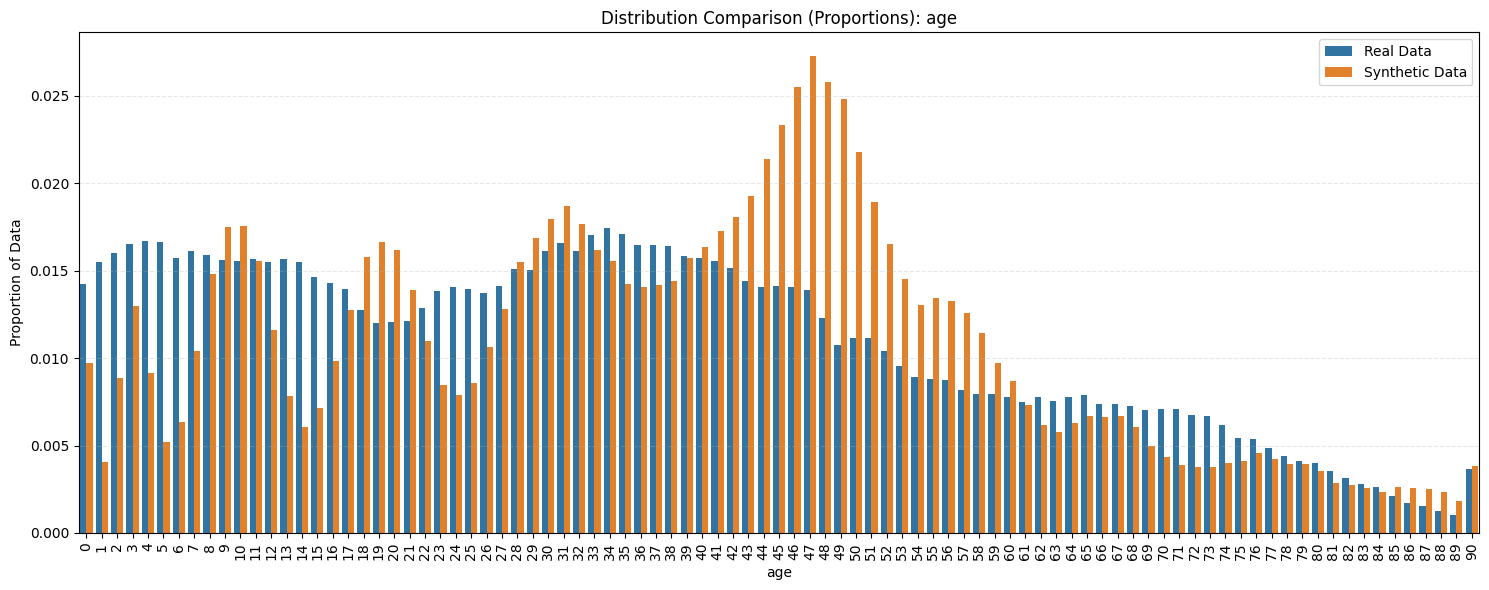

In [19]:
# CTGAN_synthesizer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Column to compare
column_to_compare = 'age'

# Calculate proportions for Real Data
real_counts = real_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
real_counts['Source'] = 'Real Data'

# Calculate proportions for Synthetic Data
synth_counts = ctgan_synth_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
synth_counts['Source'] = 'Synthetic Data'

# Combine the proportion data
combined_probs = pd.concat([real_counts, synth_counts])

plt.figure(figsize=(15, 6))

# Plot proportions instead of raw counts
sns.barplot(data=combined_probs, x=column_to_compare, y='proportion', hue='Source')

plt.title(f"Distribution Comparison (Proportions): {column_to_compare}")
plt.xlabel(column_to_compare)
plt.ylabel("Proportion of Data")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

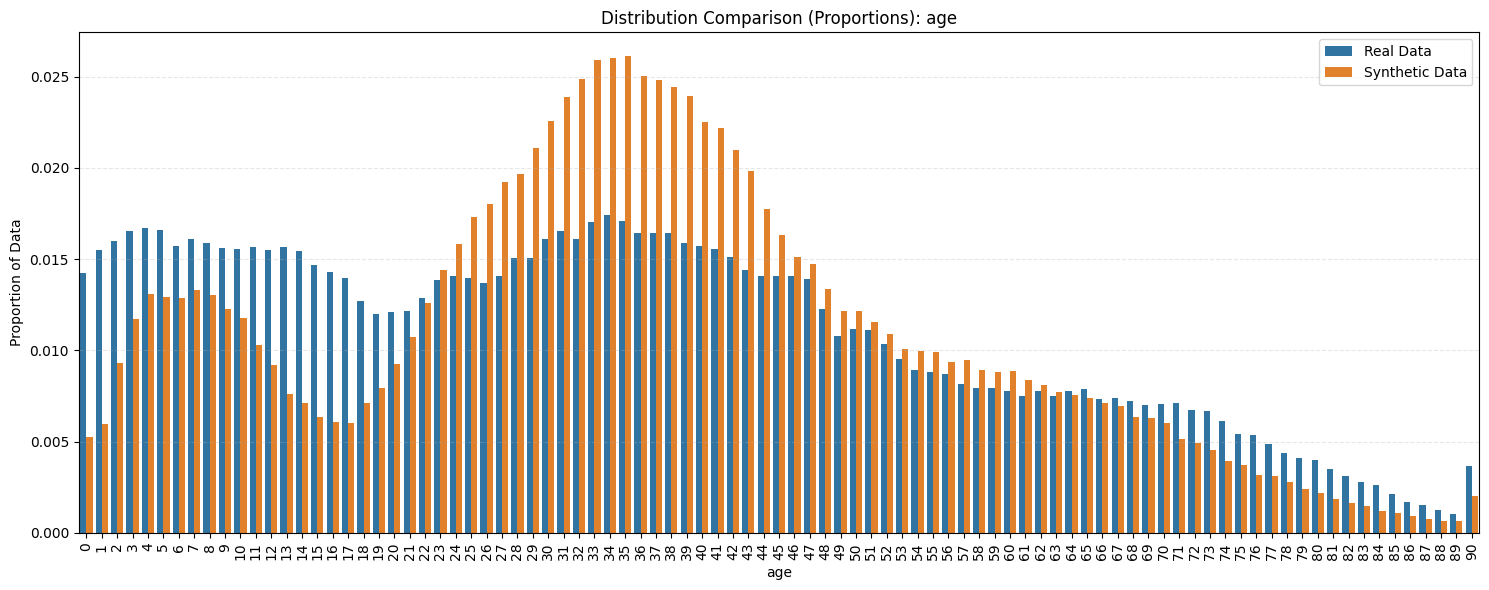

In [20]:
# TVAE_synthesizer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Column to compare
column_to_compare = 'age'

# Calculate proportions for Real Data
real_counts = real_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
real_counts['Source'] = 'Real Data'

# Calculate proportions for Synthetic Data
synth_counts = tvae_synth_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
synth_counts['Source'] = 'Synthetic Data'

# Combine the proportion data
combined_probs = pd.concat([real_counts, synth_counts])

plt.figure(figsize=(15, 6))

# Plot proportions instead of raw counts
sns.barplot(data=combined_probs, x=column_to_compare, y='proportion', hue='Source')

plt.title(f"Distribution Comparison (Proportions): {column_to_compare}")
plt.xlabel(column_to_compare)
plt.ylabel("Proportion of Data")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Multi-Objective-Loss-Function

To modify the loss function of the sdv synthesizer, we have to patch the synthesizer-code locally. Because sdv does not have a built-in API for multi-objective-loss.

### CTGAN Synthesizer

In [14]:
!pip install sdv
!cp /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/ctgan.py /content/ctgan_patched.py


In [ ]:
"""
TODO: maybe faster mmd variant? play around with loss weights

# After the imports paste this function:
# === MMD (RBF Kernel) ===
def mmd_rbf(x, y, sigma=1.0):
    """Compute MMD with RBF kernel between two batches x and y."""
    # Ensure float32
    x = x.float()
    y = y.float()

    # Compute squared norms
    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    # Kernel matrices
    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))
    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))
    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

def soft_f1_loss(fake, real):
    eps = 1e-8
    fake = fake.float()
    real = real.float()

    tp = (fake * real).sum()
    fp = (fake * (1 - real)).sum()
    fn = ((1 - fake) * real).sum()

    soft_f1 = tp / (tp + 0.5 * (fp + fn) + eps)
    return 1 - soft_f1



# Find this code:
loss_g = -torch.mean(y_fake) + cross_entropy

# and replace it by this code block:

# detach tensors that should not backprop through discriminator graph
real_detached = real.detach()
fake_detached = fakeact.detach()

# Original GAN loss
gan_loss = -torch.mean(y_fake)

# Conditional loss
cond_loss = cross_entropy

# === Additional Multi-Objective Losses ===

# MMD loss
mmd_loss = mmd_rbf(fake_detached, real_detached)

# Soft-F1 loss
utility_loss = soft_f1_loss(fake_detached, real_detached)

# Privacy loss
privacy_loss = torch.mean(torch.relu(1.0 - torch.norm(fake_detached - real_detached, dim=1)))

# Combine losses
loss_g = (
    1.0 * gan_loss +
    0.1 * mmd_loss +
    0.01 * utility_loss +
    0.01 * privacy_loss +
    cond_loss
)
"""

'\n# Find this code: \nloss_g = -torch.mean(y_fake) + cross_entropy\n\n# and replace it by this code block:\n\n# Original GAN loss\ngan_loss = -torch.mean(y_fake)\n\n# Optional: Conditional loss (already in CTGAN)\ncond_loss = cross_entropy\n\n# === Additional Multi-Objective Losses ===\n\n# 1) MMD loss (numerical similarity)\ndef mmd_rbf(x, y, sigma=1.0):\n    xx = torch.mm(x, x.t())\n    yy = torch.mm(y, y.t())\n    xy = torch.mm(x, y.t())\n\n    rx = (xx.diag().unsqueeze(0).expand_as(xx))\n    ry = (yy.diag().unsqueeze(0).expand_as(yy))\n\n    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))\n    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))\n    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))\n\n    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()\n\n# Extract numerical columns only (optional but recommended)\nreal_num = real_cat[:, :train_data.shape[1]]\nfake_num = fake_cat[:, :train_data.shape[1]]\n\nmmd_loss = mmd_rbf(fake_num, real_num)\n\n# 2) Sof

In [17]:
# Copy it back to the ctgan module
!cp /content/ctgan_patched.py /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/ctgan.py

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

In [18]:
# Train the modified ctgan
from sdv.single_table import CTGANSynthesizer

ctgan_synthesizer = CTGANSynthesizer(metadata, epochs=150, verbose=True)
ctgan_synthesizer.fit(real_data)

ctgan_synth_data = ctgan_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_modified_CTGAN_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_modified_CTGAN_300000.csv")

Gen. (-01.32) | Discrim. (-00.07): 100%|██████████| 150/150 [00:07<00:00, 18.88it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### TVAE Synthesizer

In [7]:
!pip install sdv
!cp /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/tvae.py /content/tvae_patched.py


In [ ]:
"""
# paste these two functions after the imports:
def mmd_rbf(x, y, sigma=1.0):
    x = x.float()
    y = y.float()

    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))
    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))
    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

def soft_f1_loss(fake, real):
    eps = 1e-8
    fake = fake.float()
    real = real.float()

    tp = (fake * real).sum()
    fp = (fake * (1 - real)).sum()
    fn = ((1 - fake) * real).sum()

    soft_f1 = tp / (tp + 0.5 * (fp + fn) + eps)
    return 1 - soft_f1


# replace the following code block:
loss = loss_1 + loss_2
loss.backward()
optimizerAE.step()


# with this code:
# === Original VAE losses ===
loss_recon = loss_1
loss_kl = loss_2

# === Additional losses (no gradients) ===
with torch.no_grad():
    real_detached = real.detach()
    fake_detached = rec.detach()

    mmd_val = mmd_rbf(fake_detached, real_detached)
    utility_val = soft_f1_loss(fake_detached, real_detached)
    privacy_val = torch.mean(torch.relu(1.0 - torch.norm(fake_detached - real_detached, dim=1)))

# === Combine losses ===
loss = (
    loss_recon +
    loss_kl +
    0.1 * mmd_val +
    0.01 * utility_val +
    0.01 * privacy_val
)

# === Backprop only through VAE ===
loss.backward()
optimizerAE.step()



"""

In [9]:
# Copy it back to the ctgan module
!cp /content/tvae_patched.py /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/tvae.py

In [11]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

In [13]:
# Train the modified tvae synthesizer
from sdv.single_table import TVAESynthesizer

tvae_synthesizer = TVAESynthesizer(metadata, epochs=150, verbose=True)
tvae_synthesizer.fit(real_data)

tvae_synth_data = tvae_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("synthetic_data_modified_TVAE_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_modified_TVAE_300000.csv")

Loss: -60.92: 100%|██████████| 150/150 [30:31<00:00, 12.21s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>